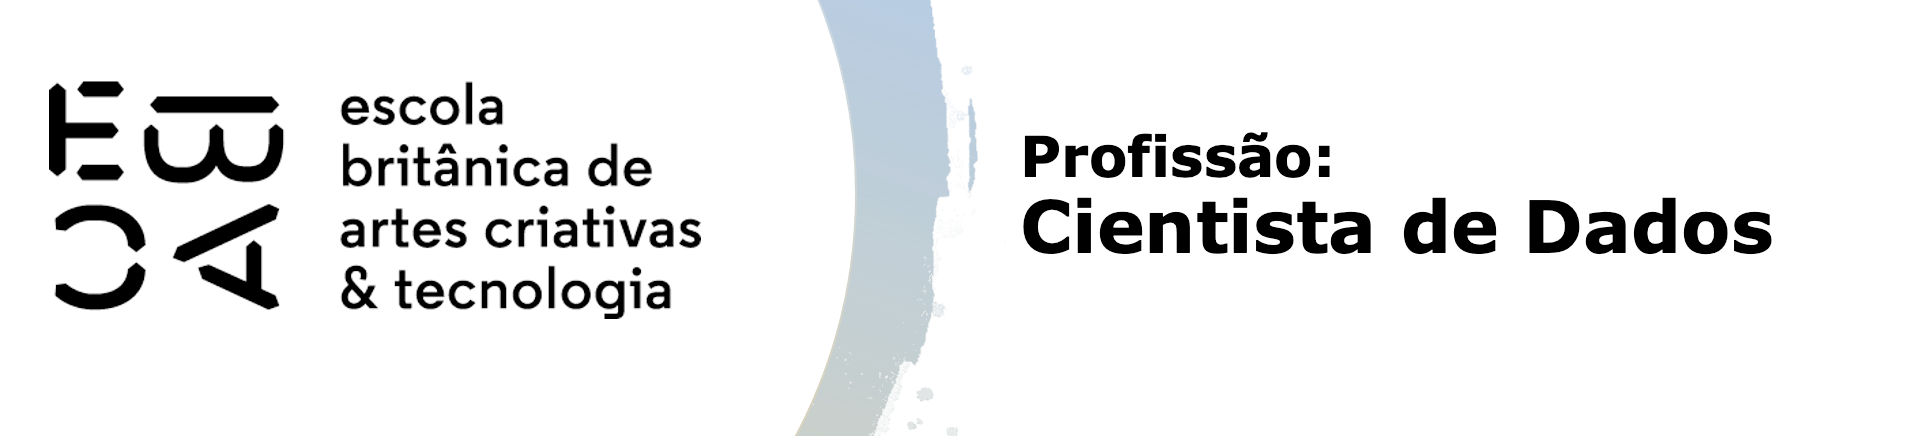

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
from sklearn import metrics
from scipy.stats import ks_2samp
from scipy.stats import t


In [2]:
df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   data_ref               750000 non-null  datetime64[ns]
 1   index                  750000 non-null  int64         
 2   sexo                   750000 non-null  object        
 3   posse_de_veiculo       750000 non-null  object        
 4   posse_de_imovel        750000 non-null  object        
 5   qtd_filhos             750000 non-null  int64         
 6   tipo_renda             750000 non-null  object        
 7   educacao               750000 non-null  object        
 8   estado_civil           750000 non-null  object        
 9   tipo_residencia        750000 non-null  object        
 10  idade                  750000 non-null  int64         
 11  tempo_emprego          624043 non-null  float64       
 12  qt_pessoas_residencia  750000 non-null  floa

In [4]:
df.dropna().sum

<bound method DataFrame.sum of          data_ref  index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
0      2015-01-01   5733    F                N               N           0   
1      2015-01-01    727    F                S               S           0   
2      2015-01-01   6374    F                N               N           2   
3      2015-01-01   9566    F                N               N           0   
4      2015-01-01   9502    F                S               N           0   
...           ...    ...  ...              ...             ...         ...   
749993 2016-03-01   7043    F                N               S           0   
749995 2016-03-01  13689    M                N               S           0   
749997 2016-03-01  14023    M                S               N           2   
749998 2016-03-01   2396    F                N               S           0   
749999 2016-03-01  14026    M                S               N           2   

         tipo_renda             

In [5]:
df.mau.value_counts()

mau
False    691357
True      58643
Name: count, dtype: int64

In [6]:
metadados = pd.DataFrame(df.dtypes, columns=['dtype'])
metadados['nmissing'] = df.isna().sum()
metadados['valores_unicos'] = df.nunique()

metadados

,dtype,nmissing,valores_unicos
data_ref,datetime64[ns],0,15
index,int64,0,16650
sexo,object,0,2
posse_de_veiculo,object,0,2
posse_de_imovel,object,0,2
qtd_filhos,int64,0,8
tipo_renda,object,0,5
educacao,object,0,5
estado_civil,object,0,5
tipo_residencia,object,0,6


In [7]:
# Transformar a variável resposta em inteiro
df['mau'] = df.mau.astype('int64')

## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [8]:
df.info

<bound method DataFrame.info of          data_ref  index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
0      2015-01-01   5733    F                N               N           0   
1      2015-01-01    727    F                S               S           0   
2      2015-01-01   6374    F                N               N           2   
3      2015-01-01   9566    F                N               N           0   
4      2015-01-01   9502    F                S               N           0   
...           ...    ...  ...              ...             ...         ...   
749995 2016-03-01  13689    M                N               S           0   
749996 2016-03-01   7000    F                N               S           0   
749997 2016-03-01  14023    M                S               N           2   
749998 2016-03-01   2396    F                N               S           0   
749999 2016-03-01  14026    M                S               N           2   

         tipo_renda            

In [9]:
df_amostra = pd.concat([df[df.mau==1], df[df.mau==0].sample(n=390)])
tab_am = df_amostra.mau.value_counts()
tab_am

mau
1    58643
0      390
Name: count, dtype: int64

In [10]:
tab_am = df.mau.value_counts()
tab_am

mau
0    691357
1     58643
Name: count, dtype: int64

In [11]:
rho_mau = tab_am.loc[1]/tab_am.sum()
rho_mau = tab_am.loc[0]/tab_am.sum()

pi_mau = tab_am.loc[1]/tab_am.sum()
pi_mau = tab_am.loc[0]/tab_am.sum()

wbom = pi_mau*rho_mau
wmau = pi_mau*rho_mau

print(f"wbom = {wbom}, wmau = {wmau}")

wbom = 0.8497324470204445, wmau = 0.8497324470204445


In [12]:
df_amostra.loc[df_amostra.mau == 1, 'w']=wmau
df_amostra.loc[df_amostra.mau == 0, 'w']=wmau

In [13]:
df_amostra.groupby('mau')['w'].sum()/df_amostra.w.sum()


mau
0    0.006606
1    0.993394
Name: w, dtype: float64

## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [14]:
df.columns

Index(['data_ref', 'index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel',
       'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil',
       'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda', 'mau'],
      dtype='object')

In [15]:
df_amostra['data_ref'] = df_amostra['idade'] / (df_amostra['qtd_filhos'] - df_amostra['tempo_emprego'])
df_amostra.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,w
9,NaN,12422,F,N,S,0,Pensionista,Médio,Casado,Casa,60,NaN,2.0,1929.08,1,0.849732
10,NaN,5159,F,N,S,0,Pensionista,Médio,Solteiro,Casa,66,NaN,1.0,4825.49,1,0.849732
19,NaN,12716,M,N,S,0,Pensionista,Médio,Casado,Aluguel,45,NaN,2.0,5101.60,1,0.849732
26,-7.107895,14106,F,N,N,0,Assalariado,Médio,Casado,Casa,37,5.205479,2.0,1400.81,1,0.849732
28,-55.914894,1744,F,N,S,0,Empresário,Médio,Viúvo,Casa,36,0.643836,1.0,1012.65,1,0.849732


In [16]:
df_amostra.describe()

,data_ref,index,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,w
count,48565.000000,59033.000000,59033.000000,59033.000000,48565.000000,59033.000000,59033.000000,59033.000000,5.903300e+04
mean,-13.112728,8469.385801,0.450731,42.734233,4.715572,2.223705,4891.557304,0.993394,8.497324e-01
std,228.090768,4831.320393,0.760914,11.587409,3.943016,0.926925,10451.871729,0.081012,3.330697e-16
min,-6205.000000,0.000000,0.000000,22.000000,0.117808,1.000000,107.670000,0.000000,8.497324e-01
25%,-20.563380,4259.000000,0.000000,33.000000,1.715068,2.000000,1305.670000,1.000000,8.497324e-01
50%,-9.441797,8595.000000,0.000000,41.000000,3.879452,2.000000,2524.260000,1.000000,8.497324e-01
75%,-5.111515,12688.000000,1.000000,52.000000,6.630137,3.000000,5185.240000,1.000000,8.497324e-01
max,3893.333333,16649.000000,14.000000,68.000000,42.906849,15.000000,989799.470000,1.000000,8.497324e-01


<Axes: ylabel='Frequency'>

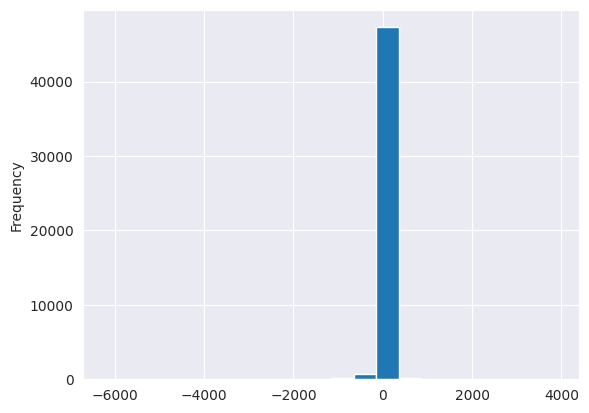

In [17]:
df_amostra['data_ref'].plot.hist(bins = 20)

In [18]:
df_amostra[df_amostra['data_ref']>.5]

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,w
30,39.408740,3586,F,N,S,2,Assalariado,Superior completo,Casado,Comunitário,42,0.934247,4.0,2527.63,1,0.849732
256,18.826955,4756,F,S,S,2,Assalariado,Superior incompleto,Casado,Casa,31,0.353425,4.0,1852.23,1,0.849732
349,37.101648,1419,F,N,S,2,Assalariado,Médio,Casado,Com os pais,37,1.002740,4.0,446.09,1,0.849732
509,1095.000000,10133,F,N,S,2,Assalariado,Médio,Casado,Casa,42,1.961644,4.0,2221.97,1,0.849732
651,51.180812,4367,M,S,S,3,Assalariado,Médio,Casado,Casa,38,2.257534,5.0,443.14,1,0.849732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118359,42.627737,1374,M,S,S,1,Empresário,Superior completo,Casado,Casa,32,0.249315,3.0,4288.77,0,0.849732
289532,47.402597,14378,F,S,S,1,Empresário,Superior completo,União,Casa,30,0.367123,3.0,21369.19,0,0.849732
663212,87.164179,14866,M,S,N,1,Assalariado,Superior incompleto,Casado,Casa,32,0.632877,3.0,1111.89,0,0.849732
638096,152.537313,8673,M,S,S,1,Empresário,Médio,Casado,Com os pais,28,0.816438,3.0,4399.80,0,0.849732


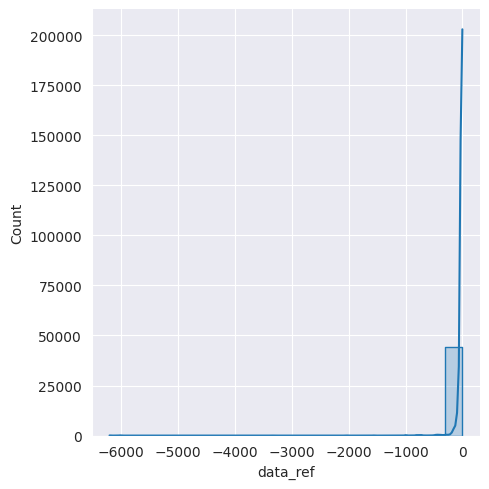

In [19]:
sns.displot(data = df_amostra[df_amostra['data_ref']<1]
            ,alpha = .25
            ,x = 'data_ref'
            ,bins = 20
            ,element = 'step'
            ,kde = True
           )

## Descritiva bivariada
*
*Faça uma análise descritiva bivariada de cada variável

In [20]:
df.columns

Index(['data_ref', 'index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel',
       'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil',
       'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda', 'mau'],
      dtype='object')

In [21]:
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rótulo_evento = tab.columns[0]
    rótulo_nao_evento = tab.columns[1]

    tab['pct_evento'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    tab['ep'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]

    tab['pct_nao_evento'] = tab[rótulo_nao_evento]/tab.loc['total',rótulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

In [22]:
iv_sexo = IV(df.sexo, df.mau)
print(f'IV da variável SEXO: {iv_sexo:.1%}')

IV da variável SEXO: 0.2%


In [23]:
metadados = pd.DataFrame(df.dtypes, columns=['dtype'])
metadados['nmissing'] = df.isna().sum()
metadados['valores_unicos'] = df.nunique()
metadados['papel'] = 'covariavel'
metadados.loc['mau','papel'] = 'resposta'
metadados.loc['bom','papel'] = 'resposta'
metadados

,dtype,nmissing,valores_unicos,papel
data_ref,datetime64[ns],0.0,15.0,covariavel
index,int64,0.0,16650.0,covariavel
sexo,object,0.0,2.0,covariavel
posse_de_veiculo,object,0.0,2.0,covariavel
posse_de_imovel,object,0.0,2.0,covariavel
qtd_filhos,int64,0.0,8.0,covariavel
tipo_renda,object,0.0,5.0,covariavel
educacao,object,0.0,5.0,covariavel
estado_civil,object,0.0,5.0,covariavel
tipo_residencia,object,0.0,6.0,covariavel


In [24]:
var='idade'
IV(pd.qcut(df[var],5,duplicates='drop'), df.mau)

np.float64(0.01796842289500074)

In [25]:
for var in metadados[metadados.papel=='covariavel'].index:
    if  (metadados.loc[var, 'valores_unicos']>6):
        metadados.loc[var, 'IV'] = IV(pd.qcut(df[var],5,duplicates='drop'), df.mau)
    else:
        metadados.loc[var, 'IV'] = IV(df[var], df.mau)


metadados

,dtype,nmissing,valores_unicos,papel,IV
data_ref,datetime64[ns],0.0,15.0,covariavel,0.345982
index,int64,0.0,16650.0,covariavel,0.002664
sexo,object,0.0,2.0,covariavel,0.002185
posse_de_veiculo,object,0.0,2.0,covariavel,0.000108
posse_de_imovel,object,0.0,2.0,covariavel,0.009693
qtd_filhos,int64,0.0,8.0,covariavel,0.000030
tipo_renda,object,0.0,5.0,covariavel,0.009360
educacao,object,0.0,5.0,covariavel,0.003547
estado_civil,object,0.0,5.0,covariavel,0.001126
tipo_residencia,object,0.0,6.0,covariavel,0.003045


In [26]:
def biv_discreta(var, df):
    df['bom'] = 1-df.mau
    g = df.groupby(var)

    biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                        'qt_mau': g['mau'].sum(),
                        'mau':g['mau'].mean(), 
                        var: g['mau'].mean().index, 
                        'cont':g[var].count()})
    
    biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
    biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
    biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep
    
    biv['logit'] = np.log(biv.mau/(1-biv.mau))
    biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
    biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

    tx_mau_geral = df.mau.mean()
    woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

    biv['woe'] = biv.logit - woe_geral
    biv['woe_sup'] = biv.logit_sup - woe_geral
    biv['woe_inf'] = biv.logit_inf - woe_geral

    fig, ax = plt.subplots(2,1, figsize=(8,6))
    ax[0].plot(biv[var], biv.woe, ':bo', label='woe')
    ax[0].plot(biv[var], biv.woe_sup, 'o:r', label='limite superior')
    ax[0].plot(biv[var], biv.woe_inf, 'o:r', label='limite inferior')
    
    num_cat = biv.shape[0]
    ax[0].set_xlim([-.3, num_cat-.7])

    ax[0].set_ylabel("Weight of Evidence")
    ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
    
    ax[0].set_xticks(list(range(num_cat)))
    ax[0].set_xticklabels(biv[var], rotation=15)
    
    ax[1] = biv.cont.plot.bar()
    return biv

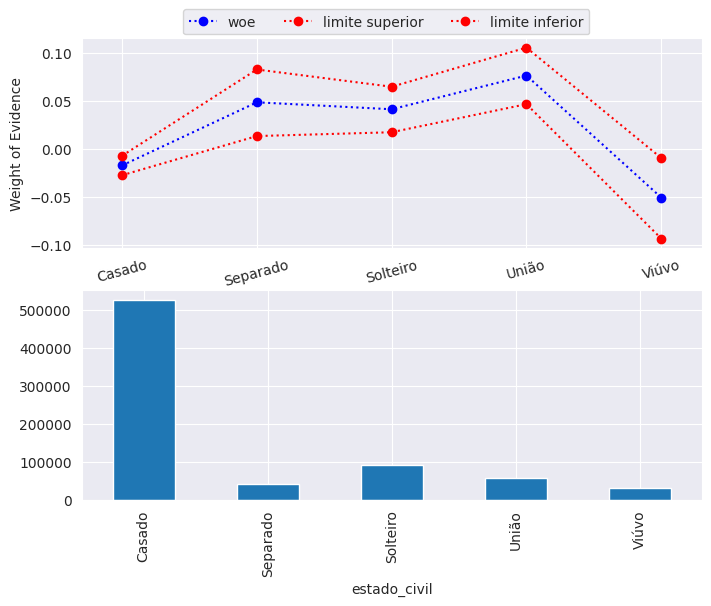

In [27]:
biv_discreta('estado_civil', df);

,qt_bom,qt_mau,mau,tipo_renda,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
tipo_renda,,,,,,,,,,,,,,
Assalariado,354527,31213,0.080917,Assalariado,385740,0.000439,0.081778,0.080057,-2.429950,-2.418434,-2.441578,0.037238,0.048754,0.025610
Bolsista,346,15,0.041551,Bolsista,361,0.010503,0.062207,0.020896,-3.138389,-2.713068,-3.847087,-0.671200,-0.245880,-1.379899
Empresário,159508,13204,0.076451,Empresário,172712,0.000639,0.077704,0.075198,-2.491574,-2.473957,-2.509458,-0.024386,-0.006769,-0.042270
Pensionista,115825,10440,0.082683,Pensionista,126265,0.000775,0.084202,0.081164,-2.406436,-2.386573,-2.426634,0.060752,0.080615,0.040555
Servidor público,61151,3771,0.058085,Servidor público,64922,0.000918,0.059884,0.056286,-2.786006,-2.753587,-2.819381,-0.318818,-0.286399,-0.352193


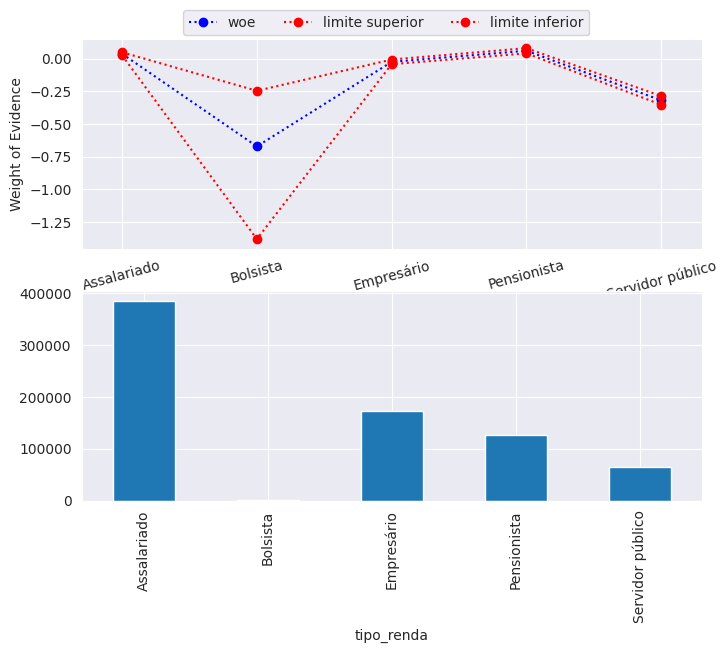

In [28]:
biv_discreta('tipo_renda', df)

/tmp/ipykernel_10340/2617695887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2.tipo_renda.replace({'Student': 'St. ser./Stud.', 'State servant': 'St. ser./Stud.'}, inplace=True)


,qt_bom,qt_mau,mau,tipo_renda,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
tipo_renda,,,,,,,,,,,,,,
Assalariado,354527,31213,0.080917,Assalariado,385740,0.000439,0.081778,0.080057,-2.429950,-2.418434,-2.441578,0.037238,0.048754,0.025610
Bolsista,346,15,0.041551,Bolsista,361,0.010503,0.062207,0.020896,-3.138389,-2.713068,-3.847087,-0.671200,-0.245880,-1.379899
Empresário,159508,13204,0.076451,Empresário,172712,0.000639,0.077704,0.075198,-2.491574,-2.473957,-2.509458,-0.024386,-0.006769,-0.042270
Pensionista,115825,10440,0.082683,Pensionista,126265,0.000775,0.084202,0.081164,-2.406436,-2.386573,-2.426634,0.060752,0.080615,0.040555
Servidor público,61151,3771,0.058085,Servidor público,64922,0.000918,0.059884,0.056286,-2.786006,-2.753587,-2.819381,-0.318818,-0.286399,-0.352193


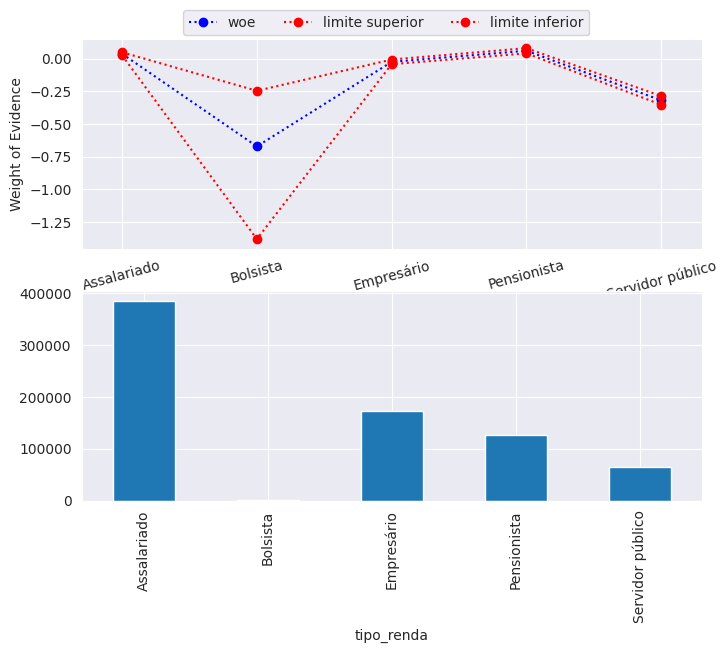

In [29]:
df2 = df.copy()
df2.tipo_renda.replace({'Student': 'St. ser./Stud.', 'State servant': 'St. ser./Stud.'}, inplace=True)
biv_discreta('tipo_renda', df2)

In [30]:
IV(df2.tipo_renda, df.mau)

np.float64(0.009360061148107996)

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


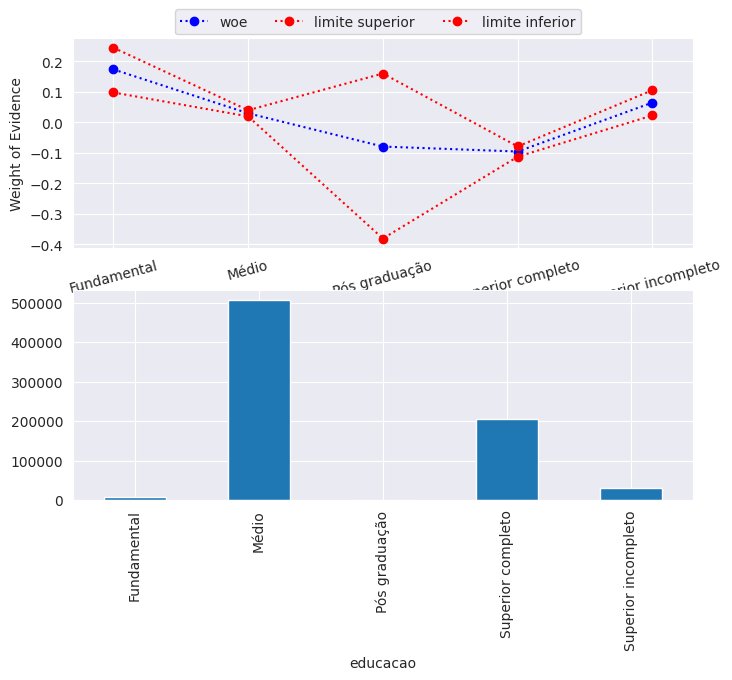

In [31]:
biv_discreta('educacao', df2)

/tmp/ipykernel_10340/3623039528.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2.educacao.replace({'Academic degree':'Academic/Higher', 'Higher education': 'Academic/Higher'}, inplace=True)


,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


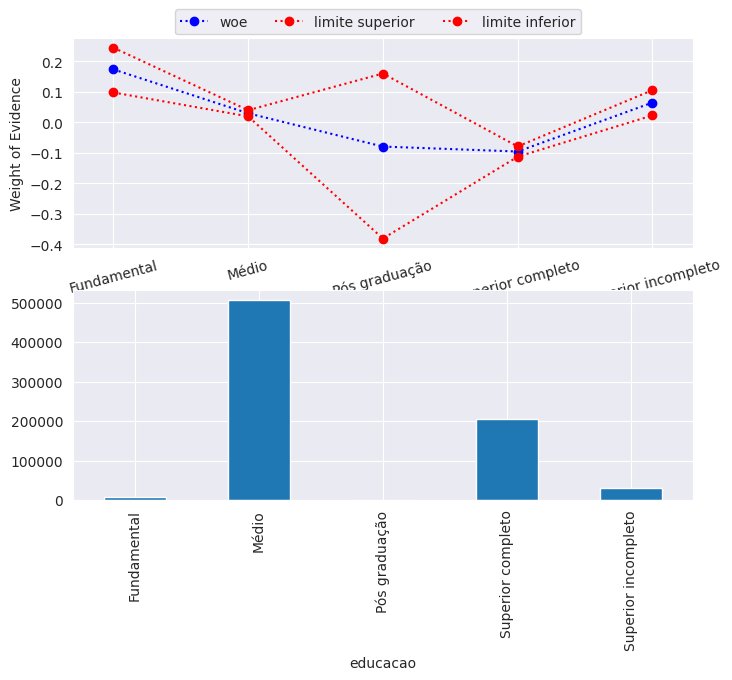

In [32]:
df2.educacao.replace({'Academic degree':'Academic/Higher', 'Higher education': 'Academic/Higher'}, inplace=True)
biv_discreta('educacao', df2)

/tmp/ipykernel_10340/1713739916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2.educacao.replace({'Incomplete higher':'Academic/Higher',


np.float64(0.0035465188386237987)

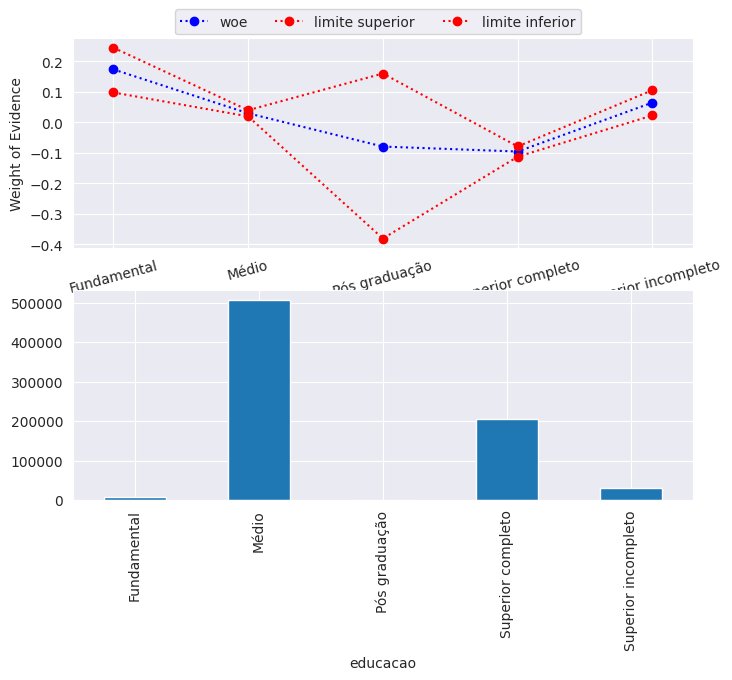

In [33]:
df2.educacao.replace({'Incomplete higher':'Academic/Higher', 
                      'Lower secondary':'lower/Secondary',
                      'Secondary / secondary special': 'lower/Secondary'
                     }, inplace=True)
biv_discreta('educacao', df2)
IV(df2.educacao, df.mau)

In [34]:

def biv_continua(var, ncat, df):
    df['bom'] = 1-df.mau
    cat_srs, bins = pd.qcut(df[var], ncat, retbins=True, precision=0, duplicates='drop')
    g = df.groupby(cat_srs)

    biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                        'qt_mau': g['mau'].sum(),
                        'mau':g['mau'].mean(), 
                        var: g[var].mean(), 
                        'cont':g[var].count()})
    
    biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
    biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
    biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep
    
    biv['logit'] = np.log(biv.mau/(1-biv.mau))
    biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
    biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

    tx_mau_geral = df.mau.mean()
    woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

    biv['woe'] = biv.logit - woe_geral
    biv['woe_sup'] = biv.logit_sup - woe_geral
    biv['woe_inf'] = biv.logit_inf - woe_geral

    fig, ax = plt.subplots(2,1, figsize=(8,6))
    ax[0].plot(biv[var], biv.woe, ':bo', label='woe')
    ax[0].plot(biv[var], biv.woe_sup, 'o:r', label='limite superior')
    ax[0].plot(biv[var], biv.woe_inf, 'o:r', label='limite inferior')
    
    num_cat = biv.shape[0]

    ax[0].set_ylabel("Weight of Evidence")
    ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
    
    ax[1] = biv.cont.plot.bar()
    return None

/tmp/ipykernel_22337/89303970.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


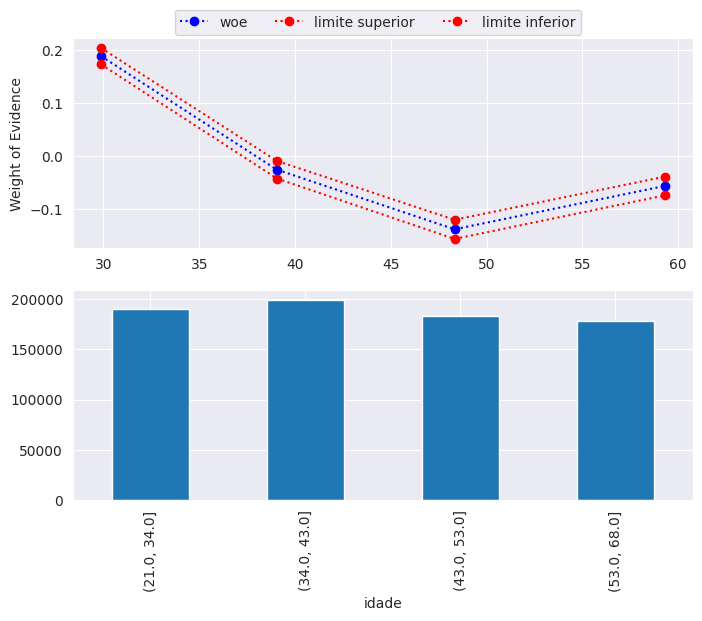

In [37]:
biv_continua('idade', 4, df)

In [35]:
df.columns
df.tempo_emprego.describe()

count    624043.000000
mean          7.748574
std           6.687455
min           0.117808
25%           3.049315
50%           6.046575
75%          10.183562
max          42.906849
Name: tempo_emprego, dtype: float64

/tmp/ipykernel_10340/89303970.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


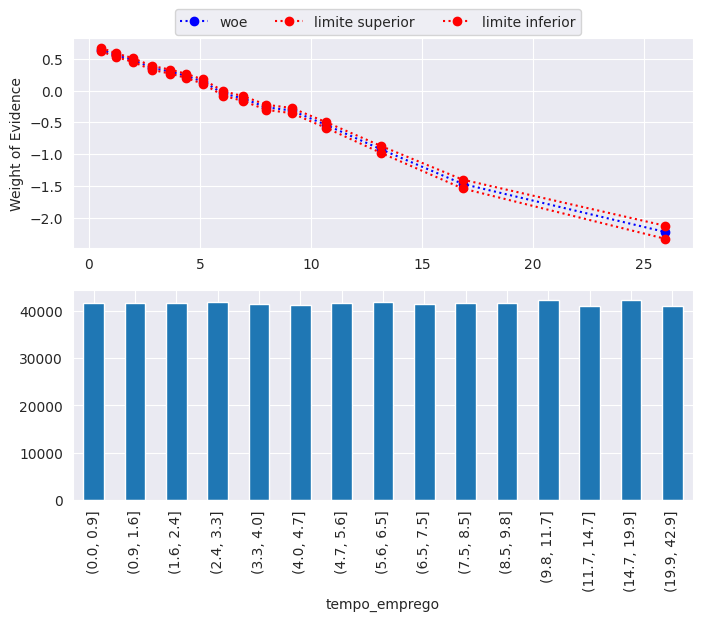

In [36]:
df2.loc[df2['tempo_emprego']<0,'tempo_emprego'] = -1
biv_continua('tempo_emprego', 15, df2)

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [38]:
# ajuda para definir a equação da regressão
' + '.join(list(df.columns))

'data_ref + index + sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda + educacao + estado_civil + tipo_residencia + idade + tempo_emprego + qt_pessoas_residencia + renda + mau + bom'

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


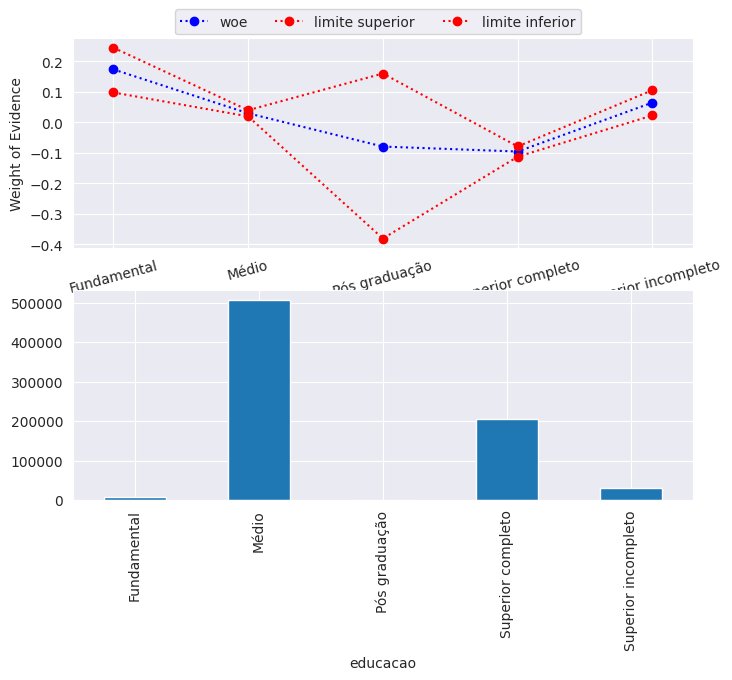

In [39]:
biv_discreta('educacao', df2)

In [40]:
df.columns

Index(['data_ref', 'index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel',
       'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil',
       'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda', 'mau', 'bom'],
      dtype='object')

In [41]:
formula = '''
    mau ~ sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda +
    educacao + estado_civil + tipo_residencia + idade + tempo_emprego +
    qt_pessoas_residencia + renda
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    mau   No. Observations:               624043
Model:                            GLM   Df Residuals:                   624017
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5064e+05
Date:                Sun, 20 Apr 2025   Deviance:                   3.0111e+05
Time:                        18:56:16   Pearson chi2:                 4.11e+16
No. Iterations:                    11   Pseudo R-squ. (CS):            0.05959
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.0117      0.169     -5.998      0.000      -1.342      -0.681
sexo[T.M]                           -0.1366      0.011    -12.377      0.000      -0.158      -0.115
posse_de_veiculo[T.S]                0.0230      0.011      2.155      0.031       0.002       0.044
posse_de_imovel[T.S]                -0.1031      0.010     -9.988      0.000      -0.123      -0.083
tipo_renda[T.Bolsista]              -0.1461      0.268     -0.544      0.586      -0.672       0.380
tipo_renda[T.Empresário]            -0.0515      0.011     -4.580      0.000      -0.074      -0.029
tipo_renda[T.Pensionista]            0.0636      0.186      0.343      0.732      -0.300       0.427
tipo_renda[T.Servidor público]      -0.0290      0.019     -1.560      0.119      -0.065       0.007
educacao[T.Médio]                   -0.0644      0.051     -1.264      0.206      -0.164       0.035
educacao[T.Pós graduação]           -0.2624      0.147     -1.786      0.074      -0.550       0.026
educacao[T.Superior completo]       -0.1326      0.052     -2.573      0.010      -0.234      -0.032
educacao[T.Superior incompleto]     -0.1077      0.055     -1.949      0.051      -0.216       0.001
estado_civil[T.Separado]            -0.0032      0.080     -0.040      0.968      -0.161       0.154
estado_civil[T.Solteiro]            -0.0110      0.079     -0.140      0.889      -0.165       0.143
estado_civil[T.União]                0.0151      0.018      0.848      0.397      -0.020       0.050
estado_civil[T.Viúvo]               -0.1521      0.086     -1.778      0.075      -0.320       0.016
tipo_residencia[T.Casa]             -0.0623      0.037     -1.702      0.089      -0.134       0.009
tipo_residencia[T.Com os pais]      -0.0574      0.041     -1.401      0.161      -0.138       0.023
tipo_residencia[T.Comunitário]      -0.1727      0.074     -2.334      0.020      -0.318      -0.028
tipo_residencia[T.Estúdio]          -0.0379      0.070     -0.539      0.590      -0.175       0.100
tipo_residencia[T.Governamental]    -0.0574      0.045     -1.267      0.205      -0.146       0.031
qtd_filhos                           0.0212      0.078      0.273      0.785      -0.131       0.173
idade                               -0.0003      0.001     -0.556      0.578      -0.001       0.001
tempo_emprego                       -0.0290      0.001    -20.523      0.000      -0.032      -0.026
qt_pessoas_residencia               -0.0218      0.078     -0.281      0.779      -0.174       0.130
renda                               -0.0001   1.14e-06   -107.676      0.000      -0.000      -0.000
====================================================================================================
"""

In [42]:
metadados.sort_values(by='IV', ascending=False)

,dtype,nmissing,valores_unicos,papel,IV
renda,float64,0.0,142419.0,covariavel,1.068628
tempo_emprego,float64,125957.0,3004.0,covariavel,0.351920
data_ref,datetime64[ns],0.0,15.0,covariavel,0.345982
idade,int64,0.0,47.0,covariavel,0.017968
posse_de_imovel,object,0.0,2.0,covariavel,0.009693
tipo_renda,object,0.0,5.0,covariavel,0.009360
educacao,object,0.0,5.0,covariavel,0.003547
tipo_residencia,object,0.0,6.0,covariavel,0.003045
index,int64,0.0,16650.0,covariavel,0.002664
sexo,object,0.0,2.0,covariavel,0.002185


In [43]:
' + '.join(list(metadados.sort_values(by='IV', ascending=False).index))

'renda + tempo_emprego + data_ref + idade + posse_de_imovel + tipo_renda + educacao + tipo_residencia + index + sexo + qt_pessoas_residencia + estado_civil + posse_de_veiculo + qtd_filhos + mau + bom'

In [48]:
formula = '''
    mau ~ tempo_emprego + estado_civil
    + idade + posse_de_imovel + tipo_renda
    + qt_pessoas_residencia + educacao
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    mau   No. Observations:               624043
Model:                            GLM   Df Residuals:                   624026
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.6191e+05
Date:                Sun, 20 Apr 2025   Deviance:                   3.2381e+05
Time:                        18:57:36   Pearson chi2:                 6.23e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02502
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.3949      0.058    -24.107      0.000      -1.508      -1.282
estado_civil[T.Separado]            0.0555      0.022      2.558      0.011       0.013       0.098
estado_civil[T.Solteiro]            0.0150      0.017      0.868      0.385      -0.019       0.049
estado_civil[T.União]               0.0265      0.017      1.518      0.129      -0.008       0.061
estado_civil[T.Viúvo]              -0.0882      0.036     -2.432      0.015      -0.159      -0.017
posse_de_imovel[T.S]               -0.2124      0.010    -21.416      0.000      -0.232      -0.193
tipo_renda[T.Bolsista]              0.0831      0.264      0.315      0.753      -0.435       0.601
tipo_renda[T.Empresário]           -0.1222      0.011    -11.075      0.000      -0.144      -0.101
tipo_renda[T.Pensionista]           0.3820      0.184      2.074      0.038       0.021       0.743
tipo_renda[T.Servidor público]     -0.0763      0.018     -4.182      0.000      -0.112      -0.041
educacao[T.Médio]                  -0.0385      0.050     -0.772      0.440      -0.136       0.059
educacao[T.Pós graduação]          -0.3261      0.145     -2.254      0.024      -0.610      -0.043
educacao[T.Superior completo]      -0.1795      0.050     -3.557      0.000      -0.278      -0.081
educacao[T.Superior incompleto]    -0.1351      0.054     -2.493      0.013      -0.241      -0.029
tempo_emprego                      -0.1220      0.001   -100.357      0.000      -0.124      -0.120
idade                              -0.0029      0.001     -5.064      0.000      -0.004      -0.002
qt_pessoas_residencia               0.0089      0.006      1.389      0.165      -0.004       0.021
===================================================================================================
"""

In [49]:
formula = '''
    mau ~ tempo_emprego + estado_civil
    + idade + posse_de_imovel
    + qt_pessoas_residencia
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    mau   No. Observations:               624043
Model:                            GLM   Df Residuals:                   624034
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.6208e+05
Date:                Sun, 20 Apr 2025   Deviance:                   3.2416e+05
Time:                        18:57:42   Pearson chi2:                 6.23e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02447
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.5754      0.031    -50.207      0.000      -1.637      -1.514
estado_civil[T.Separado]     0.0568      0.022      2.617      0.009       0.014       0.099
estado_civil[T.Solteiro]     0.0083      0.017      0.480      0.631      -0.026       0.042
estado_civil[T.União]        0.0259      0.017      1.484      0.138      -0.008       0.060
estado_civil[T.Viúvo]       -0.0724      0.036     -2.001      0.045      -0.143      -0.001
posse_de_imovel[T.S]        -0.2181      0.010    -22.036      0.000      -0.237      -0.199
tempo_emprego               -0.1221      0.001   -101.055      0.000      -0.124      -0.120
idade                       -0.0015      0.001     -2.772      0.006      -0.003      -0.000
qt_pessoas_residencia        0.0122      0.006      1.899      0.058      -0.000       0.025
============================================================================================
"""

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


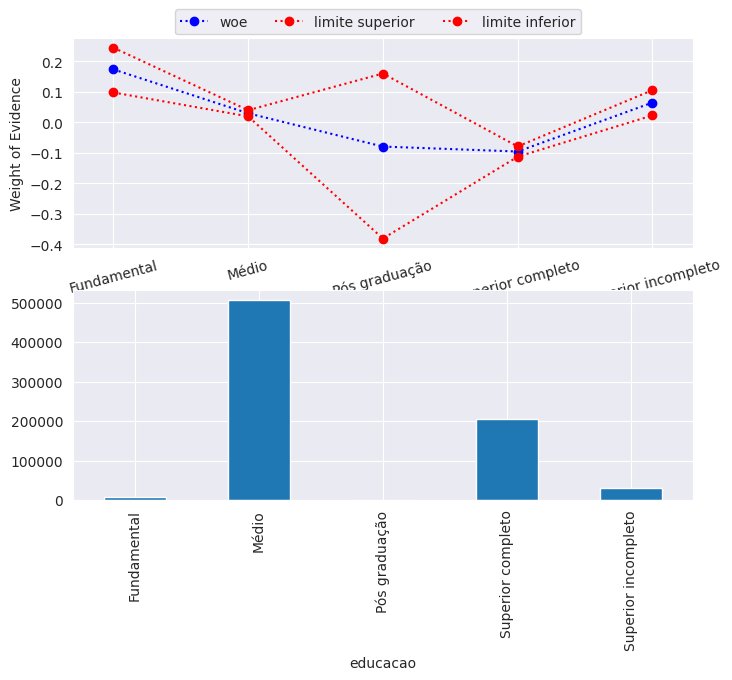

In [50]:
biv_discreta('educacao', df2)

In [51]:
df2['score'] = rl.predict(df2)

# Acurácia
acc = metrics.accuracy_score(df2.mau, df2.score>.068)
#
# Remove rows with NaN values before calculating metrics
df2_clean = df2.dropna(subset=['mau', 'score'])
fpr, tpr, thresholds = metrics.roc_curve(df2_clean.mau, df2_clean.score)

auc = metrics.auc(fpr, tpr)
#Gini
gini = 2*auc -1
ks = ks_2samp(df2.loc[df2.mau == 1, 'score'], df2.loc[df2.mau != 1, 'score']).statistic

print('Acurácia: {0:.1%} \nAUC: {1:.1%} \nGINI: {2:.1%}\nKS: {3:.1%}'
      .format(acc, auc, gini, ks))

Acurácia: 54.3% 
AUC: 65.9% 
GINI: 31.8%
KS: nan%


## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [63]:
# Separar dados de desenvolvimento e out-of-time
datas = pd.to_datetime(df2.data_ref).sort_values().unique()
data_corte = datas[-3]  # 3 últimos meses para OOT

df_dev = df2[pd.to_datetime(df2.data_ref) < data_corte].copy()
df_oot = df2[pd.to_datetime(df2.data_ref) >= data_corte].copy()

# Calcular scores para ambas as bases
df_dev['score'] = rl.predict(df_dev)
df_oot['score'] = rl.predict(df_oot)


# Função para calcular métricas
def calc_metricas(df, nome):
    acc = metrics.accuracy_score(df.mau, df.score > 0.068)

    # Remove rows with NaN values
    df_clean = df.dropna(subset=['mau', 'score'])
    fpr, tpr, _ = metrics.roc_curve(df_clean.mau, df_clean.score)

    auc = metrics.auc(fpr, tpr)
    gini = 2 * auc - 1
    ks = ks_2samp(df.loc[df.mau == 1, 'score'],
                  df.loc[df.mau != 1, 'score']).statistic

    print(f"\nMétricas para {nome}:")
    print(f"Acurácia: {acc:.1%}")
    print(f"AUC: {auc:.1%}")
    print(f"GINI: {gini:.1%}")
    print(f"KS: {ks:.1%}")

In [64]:
# Calcular métricas para desenvolvimento e OOT
calc_metricas(df_dev, "Base de Desenvolvimento")
calc_metricas(df_oot, "Base Out-of-Time")


Métricas para Base de Desenvolvimento:
Acurácia: 53.9%
AUC: 66.0%
GINI: 32.1%
KS: nan%

Métricas para Base Out-of-Time:
Acurácia: 55.9%
AUC: 66.4%
GINI: 32.8%
KS: nan%
